# Actividad Integradora sobre el Impacto de la IA generativa en estudiantes

**Extraccion del conocimiento en Bases de datos** Grupo 9C

**Integrantes:**
- Arias Hernandez Jose
- Bertadillo Villalobos Leobardo Daniel
- Paredes Dominguez Jassiel
- Aguilar Garcia Angel Gabriel
- Torres Galvan Alejandro Aldahir

Este trabajo sigue la metodologia **KDD** (*Knowledge Discovery in Databases*) para
analizar un conjunto de datos sobre el uso de la inteligencia artificial generativa
por parte de estudiantes universitarios. El objetivo es construir un modelo
supervisado que prediga el **nivel de burnout** (agotamiento) de un estudiante
a partir de sus habitos de estudio y de uso de IA. Se comparan tres algoritmos de
clasificacion vistos en clase: **arbol de decision**, **KNN** y **SVM**.

Las etapas de KDD que se recorren son: seleccion, preprocesamiento/limpieza,
transformacion, mineria de datos y, por ultimo, interpretacion y evaluacion.

## 1. Importar librerias

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

sns.set_style("whitegrid")

# Semilla fija para que el experimento de siempre el mismo resultado
RNG = 42

# Orden fijo de las clases (de menor a mayor agotamiento)
orden = ["Low", "Medium", "High"]

## 2. Seleccion del dataset (KDD: Seleccion)

El conjunto de datos **AI Student Impact** proviene de Kaggle y simula el impacto del
uso de IA generativa en el desempeno academico de estudiantes universitarios.
Tiene **50,000 registros** y **16 columnas**. Cada fila es un estudiante descrito por
sus datos academicos (carrera, ano, promedio antes y despues del semestre), sus
habitos de uso de IA (horas semanales, tipo de uso, nivel de habilidad para escribir
prompts, diversidad de herramientas) y algunas medidas de resultado (retencion de
habilidades, ansiedad en examenes y nivel de burnout).

La variable que queremos predecir es **`Burnout_Risk_Level`**, con tres categorias:
`Low`, `Medium` y `High`. Se trata entonces de un problema de **clasificacion de
tres clases**.

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
# Tamano del conjunto y tipos de dato
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.info()

Filas: 50000 | Columnas: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Pos

## 3. Preprocesamiento y limpieza (KDD: Preprocesamiento)

En esta etapa se revisa la calidad de los datos: valores faltantes, filas
duplicadas y columnas que no aportan al analisis.

In [4]:
# Revision de datos faltantes y duplicados
print("Valores nulos en total:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos en total: 0
Filas duplicadas: 0


In [5]:
# Student_ID es solo un identificador, no aporta informacion para clasificar.
# Se elimina para que no confunda a los modelos.
df = df.drop(columns=["Student_ID"])
print("Columnas restantes:", df.shape[1])

Columnas restantes: 15


In [6]:
# Estadisticas descriptivas de las variables numericas
df.describe().round(2)

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,3.15,8.43,2.80,11.21,3.51,4.27,3.35,75.80
std,0.48,8.27,1.19,5.16,1.82,2.14,0.50,13.28
min,1.18,0.00,1.00,1.00,1.00,1.00,1.00,10.78
25%,2.83,2.39,2.00,7.56,2.00,3.00,3.02,66.82
50%,3.21,5.80,3.00,11.18,3.00,4.00,3.42,76.00
75%,3.52,11.72,4.00,14.71,5.00,6.00,3.75,85.19
max,4.00,40.00,5.00,35.86,10.00,10.00,4.00,100.00


El conjunto esta muy limpio: no tiene valores nulos ni filas duplicadas, por lo que
no se requiere imputar ni eliminar registros. A continuacion se revisa como se
distribuye la clase que queremos predecir.

In [7]:
# Distribucion de la clase objetivo
conteo = df["Burnout_Risk_Level"].value_counts().reindex(orden)
print(conteo)
print()
print((100 * conteo / len(df)).round(2))

Burnout_Risk_Level
Low       16369
Medium    21144
High      12487
Name: count, dtype: int64

Burnout_Risk_Level
Low       32.74
Medium    42.29
High      24.97
Name: count, dtype: float64


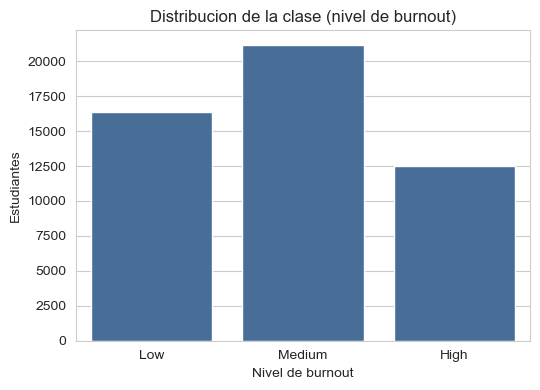

In [8]:
plt.figure(figsize=(5.5, 4))
sns.countplot(data=df, x="Burnout_Risk_Level", order=orden, color="#3b6ea5")
plt.title("Distribucion de la clase (nivel de burnout)")
plt.xlabel("Nivel de burnout")
plt.ylabel("Estudiantes")
plt.tight_layout()
plt.show()

Las tres clases no estan perfectamente balanceadas: `Medium` es la mas comun (42%)
y `High` la menos frecuente (25%). No es un desbalance grave, pero conviene apoyarse
tambien en el **Macro F1**, que trata a las tres clases por igual, y no solo en la
exactitud.

Ahora comparamos el promedio de algunas variables segun el nivel de burnout, para
ver que factores parecen relacionarse con el.

In [9]:
# Promedio de variables clave por nivel de burnout
df.groupby("Burnout_Risk_Level")[
    ["Weekly_GenAI_Hours", "Traditional_Study_Hours", "Perceived_AI_Dependency",
     "Anxiety_Level_During_Exams", "Skill_Retention_Score"]
].mean().reindex(orden).round(2)

,Weekly_GenAI_Hours,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score
Burnout_Risk_Level,,,,,
Low,4.64,11.97,2.82,3.93,76.40
Medium,7.35,11.29,3.36,4.17,76.24
High,15.21,10.08,4.64,4.89,74.25


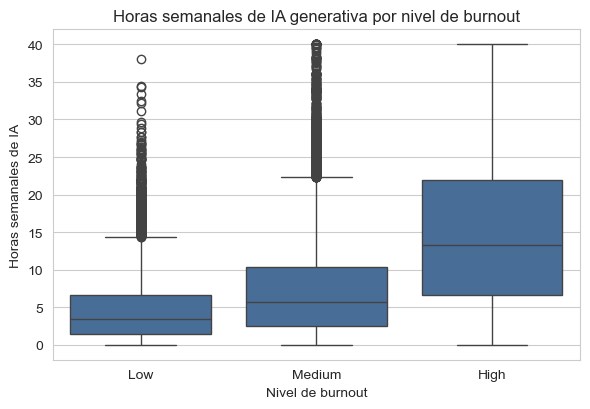

In [10]:
# Las horas de IA por semana suben mucho conforme aumenta el burnout
plt.figure(figsize=(6, 4.2))
sns.boxplot(data=df, x="Burnout_Risk_Level", y="Weekly_GenAI_Hours", order=orden, color="#3b6ea5")
plt.title("Horas semanales de IA generativa por nivel de burnout")
plt.xlabel("Nivel de burnout")
plt.ylabel("Horas semanales de IA")
plt.tight_layout()
plt.show()

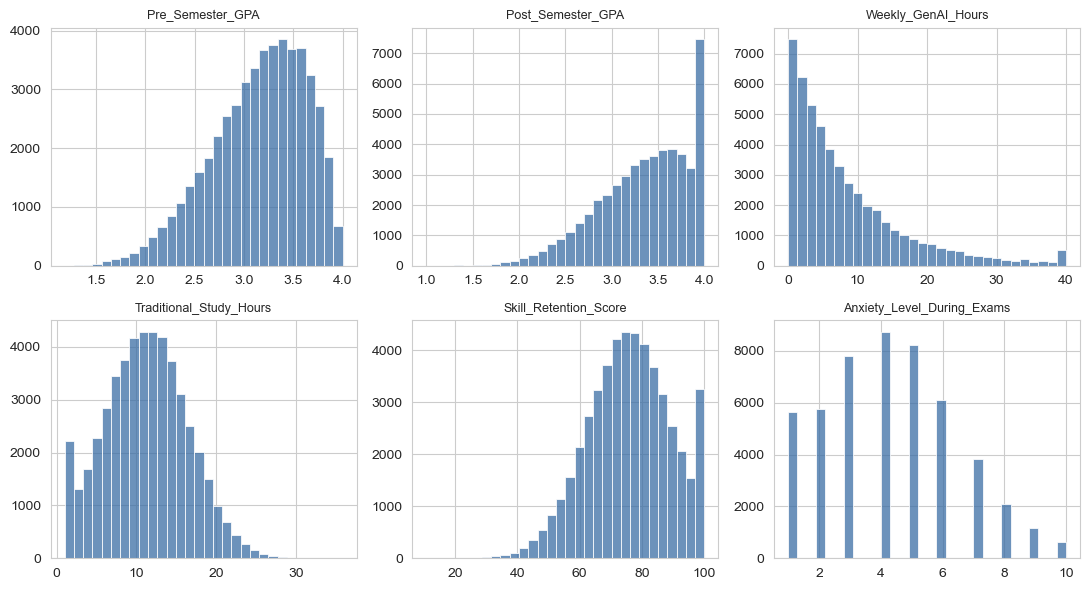

In [11]:
# Distribucion de las variables numericas mas importantes
claves = ["Pre_Semester_GPA", "Post_Semester_GPA", "Weekly_GenAI_Hours",
          "Traditional_Study_Hours", "Skill_Retention_Score", "Anxiety_Level_During_Exams"]
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, col in zip(axes.ravel(), claves):
    sns.histplot(df[col], bins=30, ax=ax, color="#3b6ea5")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

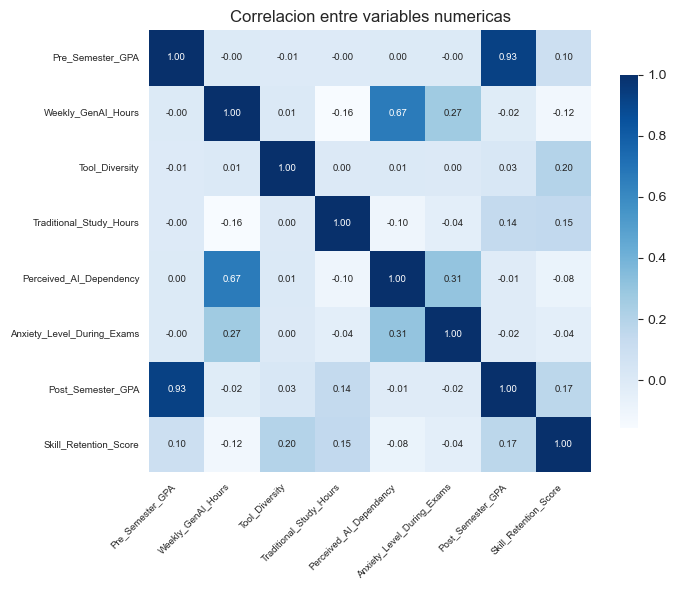

In [12]:
# Mapa de correlacion entre las variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(7.5, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="Blues", square=True,
            cbar_kws={"shrink": .8}, annot_kws={"size": 7})
plt.title("Correlacion entre variables numericas")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 4. Transformacion de datos (KDD: Transformacion)

Antes de entrenar los modelos se preparan los datos en tres pasos:

1. **Variable derivada.** Se crea `GPA_Change` como la diferencia entre el promedio
   final y el inicial, para capturar si el estudiante mejoro o empeoro.
2. **Codificacion de variables categoricas.** Los modelos solo trabajan con numeros,
   asi que las columnas de texto (carrera, ano, tipo de uso, etc.) se convierten en
   columnas numericas con *one-hot encoding*.
3. **Division y estandarizacion.** Se separan los datos en entrenamiento y prueba de
   forma estratificada, y se estandarizan las variables (media 0 y desviacion 1)
   porque KNN y SVM dependen de distancias.

In [13]:
# 1. Variable derivada: cambio en el promedio
df["GPA_Change"] = (df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]).round(3)
df["GPA_Change"].describe().round(3)

count    50000.000
mean         0.203
std          0.187
min         -0.924
25%          0.087
50%          0.204
75%          0.325
max          1.008
Name: GPA_Change, dtype: float64

In [14]:
# 2. Separar la clase y codificar las variables categoricas
y = df["Burnout_Risk_Level"]
X = pd.get_dummies(df.drop(columns=["Burnout_Risk_Level"]), drop_first=True)
print("Numero de variables tras la codificacion:", X.shape[1])
X.head()

Numero de variables tras la codificacion: 26


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Change,...,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,2.418,23.31,1,True,8.13,5,6,2.393,86.44,-0.025,...,True,False,False,False,False,False,True,False,True,False
1,3.821,1.12,5,False,16.65,3,9,3.696,69.39,-0.125,...,False,False,False,False,True,False,False,False,True,False
2,3.398,21.26,2,False,10.35,5,9,3.499,73.93,0.101,...,False,False,False,False,False,True,True,False,False,True
3,3.789,1.82,4,False,15.23,2,2,4.000,63.58,0.211,...,True,False,False,False,False,False,False,True,True,False
4,3.635,9.29,4,False,12.55,4,4,3.798,100.00,0.163,...,False,True,True,False,False,False,False,False,True,False


In [15]:
# 3. Division estratificada 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=y)
print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])

# La escala se aprende solo con los datos de entrenamiento y se aplica a ambos
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Entrenamiento: 40000 | Prueba: 10000


## 5. Funciones para calcular las metricas a mano

Igual que en las actividades anteriores, las metricas se calculan **a mano** a partir
de la matriz de confusion, usando el esquema *una clase contra el resto*. Para cada
clase se cuentan los verdaderos positivos (TP), falsos negativos (FN), falsos
positivos (FP) y verdaderos negativos (TN), y con ellos se obtienen precision,
sensibilidad, especificidad y F1.

In [16]:
def matriz_confusion(y_real, y_pred, etiquetas):
    # Cuenta cuantas veces la clase real se predijo como cada clase
    idx = {c: i for i, c in enumerate(etiquetas)}
    m = np.zeros((len(etiquetas), len(etiquetas)), dtype=int)
    for real, pred in zip(y_real, y_pred):
        m[idx[real], idx[pred]] += 1
    return m


def metricas_por_clase(cm, etiquetas):
    # Aplica el esquema una contra el resto a cada clase
    total = cm.sum()
    filas = []
    for i, c in enumerate(etiquetas):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        prec = TP / (TP + FP) if TP + FP else 0
        rec = TP / (TP + FN) if TP + FN else 0
        spec = TN / (TN + FP) if TN + FP else 0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0
        filas.append([c, TP, FN, FP, TN, round(prec, 4), round(rec, 4),
                      round(spec, 4), round(f1, 4)])
    return pd.DataFrame(filas, columns=["Clase", "TP", "FN", "FP", "TN",
                                        "Precision", "Sensibilidad", "Especificidad", "F1"])


def accuracy_global(cm):
    # Aciertos (diagonal) entre el total
    return np.trace(cm) / cm.sum()


def macro_f1(tabla):
    # Promedio simple del F1 de las tres clases
    return tabla["F1"].mean()


def graficar_matriz(cm, etiquetas, titulo):
    plt.figure(figsize=(4.8, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=etiquetas, yticklabels=etiquetas, cbar=False)
    plt.title(titulo)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

# Aqui se iran guardando los resultados de cada modelo para compararlos al final
resultados = {}

## 6. Mineria de datos: Arbol de decision (KDD: Mineria)

El primer modelo es un **arbol de decision**. Es facil de interpretar y, al no basarse
en distancias, se puede entrenar directamente con las variables sin estandarizar.
Se busca la mejor profundidad y el minimo de muestras por hoja con validacion cruzada.

In [17]:
rejilla_arbol = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 5, 20, 50],
}
busqueda_arbol = GridSearchCV(DecisionTreeClassifier(random_state=RNG),
                              rejilla_arbol, cv=5, scoring="accuracy", n_jobs=-1)
busqueda_arbol.fit(X_train, y_train)
print("Mejor configuracion:", busqueda_arbol.best_params_)
print("Accuracy CV:", round(busqueda_arbol.best_score_, 4))

Mejor configuracion: {'max_depth': 6, 'min_samples_leaf': 50}
Accuracy CV: 0.523


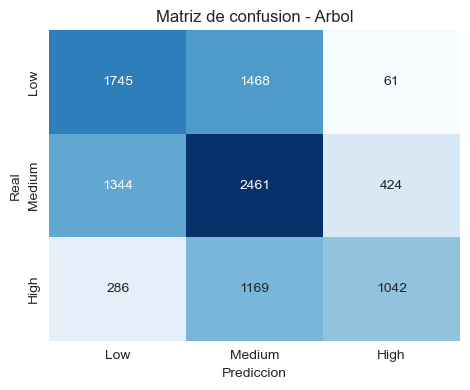

In [18]:
# Entrenamiento y prediccion con la mejor configuracion
arbol = busqueda_arbol.best_estimator_

inicio = time.time()
arbol.fit(X_train, y_train)
t_entren_arbol = time.time() - inicio

inicio = time.time()
y_arbol = arbol.predict(X_test)
t_predic_arbol = time.time() - inicio

cm_arbol = matriz_confusion(list(y_test), list(y_arbol), orden)
graficar_matriz(cm_arbol, orden, "Matriz de confusion - Arbol")

In [19]:
tabla_arbol = metricas_por_clase(cm_arbol, orden)
print("Accuracy:", round(accuracy_global(cm_arbol), 4),
      "| Macro F1:", round(macro_f1(tabla_arbol), 4))
resultados["Arbol"] = (accuracy_global(cm_arbol), macro_f1(tabla_arbol),
                       t_entren_arbol, t_predic_arbol)
tabla_arbol

Accuracy: 0.5248 | Macro F1: 0.5235


,Clase,TP,FN,FP,TN,Precision,Sensibilidad,Especificidad,F1
0,Low,1745,1529,1630,5096,0.5170,0.5330,0.7577,0.5249
1,Medium,2461,1768,2637,3134,0.4827,0.5819,0.5431,0.5277
2,High,1042,1455,485,7018,0.6824,0.4173,0.9354,0.5179


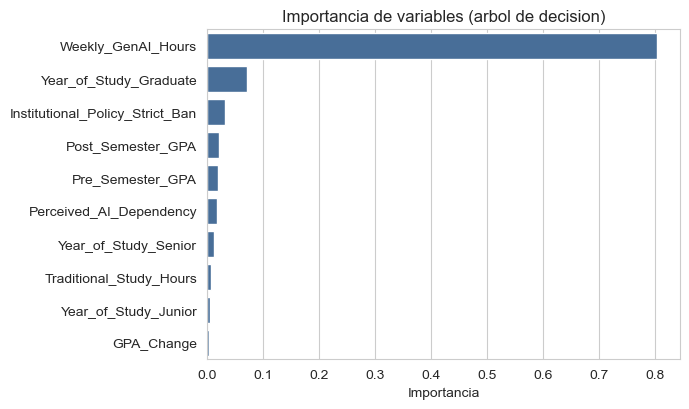

Weekly_GenAI_Hours                 0.8038
Year_of_Study_Graduate             0.0715
Institutional_Policy_Strict_Ban    0.0329
Post_Semester_GPA                  0.0221
Pre_Semester_GPA                   0.0204
Perceived_AI_Dependency            0.0177
Year_of_Study_Senior               0.0122
Traditional_Study_Hours            0.0073
Year_of_Study_Junior               0.0058
GPA_Change                         0.0031
dtype: float64

In [20]:
# Que variables usa mas el arbol para decidir
importancia = pd.Series(arbol.feature_importances_, index=X.columns)
importancia = importancia.sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 4.2))
sns.barplot(x=importancia.values, y=importancia.index, color="#3b6ea5")
plt.title("Importancia de variables (arbol de decision)")
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.show()
importancia.round(4)

## 7. Mineria de datos: KNN (KDD: Mineria)

El segundo modelo es **K-Vecinos mas Cercanos**. Clasifica cada estudiante segun la
clase mas comun entre sus vecinos mas parecidos. Como se basa en distancias, se usan
los datos **estandarizados**. Se prueban varios valores de `k` con validacion cruzada
y se elige el mejor.

In [21]:
valores_k = [5, 11, 21, 31, 41, 61, 81, 101]
promedios = []
for k in valores_k:
    puntajes = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                               X_train_s, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    promedios.append(puntajes.mean())
    print(f"k = {k:3d}  ->  accuracy CV = {puntajes.mean():.4f}")

mejor_k = valores_k[int(np.argmax(promedios))]
print("\nMejor k:", mejor_k)

k =   5  ->  accuracy CV = 0.4421
k =  11  ->  accuracy CV = 0.4693
k =  21  ->  accuracy CV = 0.4834
k =  31  ->  accuracy CV = 0.4898
k =  41  ->  accuracy CV = 0.4915
k =  61  ->  accuracy CV = 0.4939
k =  81  ->  accuracy CV = 0.4977
k = 101  ->  accuracy CV = 0.4995

Mejor k: 101


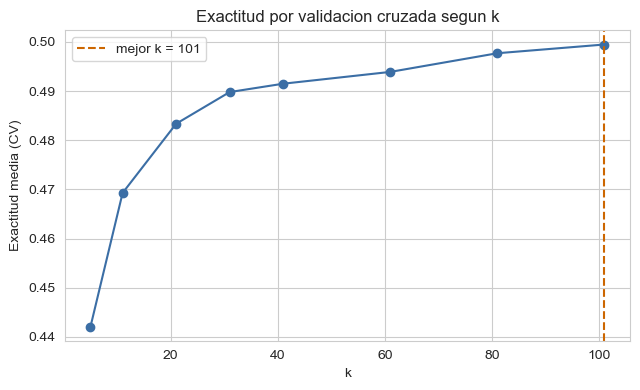

In [22]:
plt.figure(figsize=(6.5, 4))
plt.plot(valores_k, promedios, marker="o", color="#3b6ea5")
plt.axvline(mejor_k, color="#cc6600", ls="--", label=f"mejor k = {mejor_k}")
plt.title("Exactitud por validacion cruzada segun k")
plt.xlabel("k")
plt.ylabel("Exactitud media (CV)")
plt.legend()
plt.tight_layout()
plt.show()

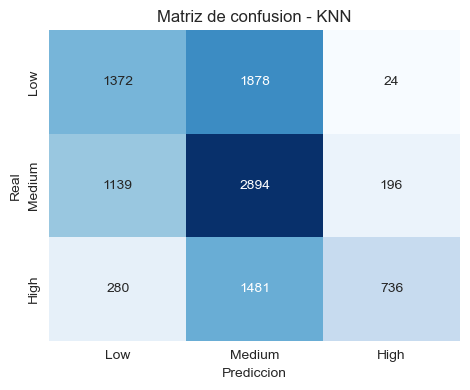

In [23]:
knn = KNeighborsClassifier(n_neighbors=mejor_k)

inicio = time.time()
knn.fit(X_train_s, y_train)
t_entren_knn = time.time() - inicio

inicio = time.time()
y_knn = knn.predict(X_test_s)
t_predic_knn = time.time() - inicio

cm_knn = matriz_confusion(list(y_test), list(y_knn), orden)
graficar_matriz(cm_knn, orden, "Matriz de confusion - KNN")

In [24]:
tabla_knn = metricas_por_clase(cm_knn, orden)
print("Accuracy:", round(accuracy_global(cm_knn), 4),
      "| Macro F1:", round(macro_f1(tabla_knn), 4))
resultados["KNN"] = (accuracy_global(cm_knn), macro_f1(tabla_knn),
                     t_entren_knn, t_predic_knn)
tabla_knn

Accuracy: 0.5002 | Macro F1: 0.477


,Clase,TP,FN,FP,TN,Precision,Sensibilidad,Especificidad,F1
0,Low,1372,1902,1419,5307,0.4916,0.4191,0.7890,0.4524
1,Medium,2894,1335,3359,2412,0.4628,0.6843,0.4180,0.5522
2,High,736,1761,220,7283,0.7699,0.2948,0.9707,0.4263


## 8. Mineria de datos: SVM (KDD: Mineria)

El tercer modelo es una **Maquina de Vectores de Soporte** con kernel RBF. Entrenar
SVM sobre las 40,000 filas de entrenamiento es muy costoso (un solo entrenamiento
tarda varios minutos y una busqueda de parametros tardaria horas). Por eso se toma una
**muestra estratificada representativa de 10,000 ejemplos** para ajustar y entrenar el
SVM. La evaluacion se hace sobre el **mismo conjunto de prueba** que los otros dos
modelos, para que la comparacion sea justa.

In [25]:
# Muestra estratificada de 10,000 ejemplos del conjunto de entrenamiento
N_SUB = 10000
X_sub, _, y_sub, _ = train_test_split(
    X_train_s, y_train, train_size=N_SUB, random_state=RNG, stratify=y_train)
print("Tamano de la muestra para SVM:", X_sub.shape[0])

Tamano de la muestra para SVM: 10000


In [26]:
# Busqueda de la mejor combinacion de C y gamma con validacion cruzada
rejilla_svm = {"C": [1, 10, 100], "gamma": ["scale", 0.1]}
busqueda_svm = GridSearchCV(SVC(kernel="rbf"), rejilla_svm, cv=5,
                            scoring="accuracy", n_jobs=-1)
busqueda_svm.fit(X_sub, y_sub)
print("Mejor configuracion:", busqueda_svm.best_params_)
print("Accuracy CV:", round(busqueda_svm.best_score_, 4))

Mejor configuracion: {'C': 1, 'gamma': 'scale'}
Accuracy CV: 0.5131


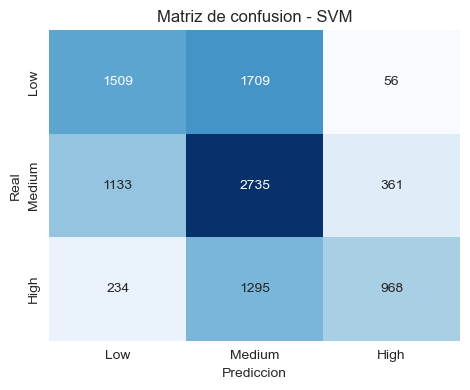

In [27]:
svm = busqueda_svm.best_estimator_

inicio = time.time()
svm.fit(X_sub, y_sub)
t_entren_svm = time.time() - inicio

inicio = time.time()
y_svm = svm.predict(X_test_s)
t_predic_svm = time.time() - inicio

cm_svm = matriz_confusion(list(y_test), list(y_svm), orden)
graficar_matriz(cm_svm, orden, "Matriz de confusion - SVM")

In [28]:
tabla_svm = metricas_por_clase(cm_svm, orden)
print("Accuracy:", round(accuracy_global(cm_svm), 4),
      "| Macro F1:", round(macro_f1(tabla_svm), 4))
resultados["SVM"] = (accuracy_global(cm_svm), macro_f1(tabla_svm),
                     t_entren_svm, t_predic_svm)
tabla_svm

Accuracy: 0.5212 | Macro F1: 0.5127


,Clase,TP,FN,FP,TN,Precision,Sensibilidad,Especificidad,F1
0,Low,1509,1765,1367,5359,0.5247,0.4609,0.7968,0.4907
1,Medium,2735,1494,3004,2767,0.4766,0.6467,0.4795,0.5488
2,High,968,1529,417,7086,0.6989,0.3877,0.9444,0.4987


## 9. Interpretacion y evaluacion (KDD: Evaluacion)

Se reunen las metricas de los tres modelos en una sola tabla y se comparan de forma
grafica.

In [29]:
comparativa = pd.DataFrame(
    resultados, index=["Accuracy", "Macro F1", "T. entren (s)", "T. predic (s)"]).T
comparativa.round(4)

,Accuracy,Macro F1,T. entren (s),T. predic (s)
Arbol,0.5248,0.5235,0.3973,0.0056
KNN,0.5002,0.4770,0.0651,3.3914
SVM,0.5212,0.5127,10.6104,9.7702


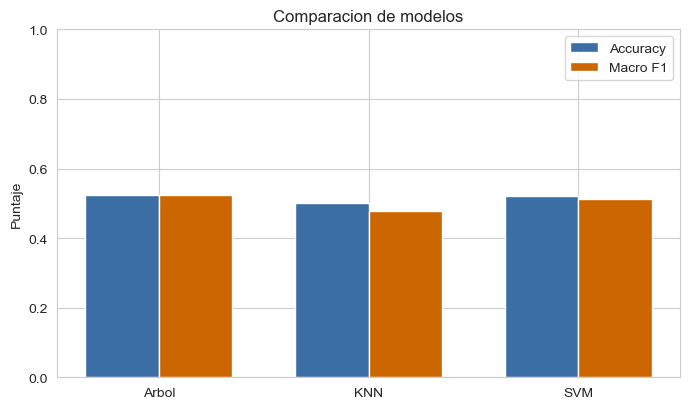

In [30]:
modelos = list(comparativa.index)
x = np.arange(len(modelos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - ancho/2, comparativa["Accuracy"], ancho, label="Accuracy", color="#3b6ea5")
ax.bar(x + ancho/2, comparativa["Macro F1"], ancho, label="Macro F1", color="#cc6600")
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 1)
ax.set_ylabel("Puntaje")
ax.set_title("Comparacion de modelos")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Conclusiones

- El **arbol de decision** obtuvo el mejor desempeno (accuracy 0.5248, Macro F1 0.5235),
  seguido muy de cerca por **SVM** (0.5212) y por **KNN** (0.5002). Las diferencias
  entre los tres son pequenas.

- La exactitud ronda el **52%**, muy por encima del **33%** que daria adivinar al azar
  entre tres clases, pero lejos de ser perfecta. Esto indica que el nivel de burnout
  solo puede predecirse **de forma parcial** con estas variables: hay una parte del
  fenomeno que depende de factores que el dataset no captura.

- La variable mas influyente, con mucha diferencia, es **`Weekly_GenAI_Hours`**
  (horas semanales de IA), que concentra alrededor del 80% de la importancia en el
  arbol. Los estudiantes con mas horas de IA tienden a un burnout mas alto, como se
  vio en el diagrama de caja.

- Las tres clases se confunden sobre todo con la clase **`Medium`**, que al estar en el
  centro comparte caracteristicas con las otras dos y es la mas dificil de separar.

- En cuanto a costo, el **arbol** es el mas practico: entrena y predice casi al
  instante. **KNN** casi no tarda en entrenar pero es lento al predecir porque compara
  cada caso con todos los ejemplos. **SVM** es el mas costoso de entrenar, por lo que
  fue necesario trabajarlo con una muestra.

En resumen, para este problema el arbol de decision ofrece el mejor equilibrio entre
desempeno, rapidez e interpretabilidad, y el analisis muestra que el uso intensivo de
IA generativa es el factor mas asociado al agotamiento de los estudiantes.